In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [5]:
df = pd.read_csv('../lesson11/ecommerce_bigdata.csv')

label_encoder = {}
categorical_columns = ['Region', 'ProductCategory', 'CustomerType'] # Replace with your categorical columns
for col in categorical_columns:
    le = LabelEncoder()
    df[col + '_Encoded'] = le.fit_transform(df[col])
    label_encoder[col] = le # Store the label encoder for future use
    print(f'Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Encoded Region: {'Central': np.int64(0), 'Eastern': np.int64(1), 'Northern': np.int64(2), 'Western': np.int64(3)}
Encoded ProductCategory: {'Beverages': np.int64(0), 'Clothing': np.int64(1), 'Electronics': np.int64(2), 'Food': np.int64(3), 'Household Products': np.int64(4)}
Encoded CustomerType: {'Online': np.int64(0), 'Retail': np.int64(1), 'Wholesale': np.int64(2)}


In [7]:
df.drop(['TransactionID','Date', 'Region', 'ProductCategory', 'CustomerType'], axis=1, inplace=True)
df.head()

,Sales,Profit,Region_Encoded,ProductCategory_Encoded,CustomerType_Encoded
0,4924,359.44,1,2,2
1,3283,944.32,0,2,1
2,4049,967.10,2,3,0
3,4331,434.57,3,4,0
4,3283,340.48,3,4,1


In [10]:
# Step 5: Split the dataset into training and testing sets
# Define features and target variable for regression task (predicting profit)
# Regression Task: Predicting Profit based on Sales
print('Regression: Predicting Profit based on Sales')

# Prepare the features (X) and target variable (y) for regression
X_reg = df.drop('Profit', axis=1)  # Features (all columns except 'Profit') Independent variables
y_reg = df['Profit']  # Target variable (Profit) Dependent variable

# Split the dataset into training and testing sets for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# What is a random state?
# A random state is a seed value that ensures reproducibility of the results.

print(f'Regression Data Split: ')
print(f"Training set size: {X_train_reg.shape[0]} samples")
print(f"Testing set size: {X_test_reg.shape[0]} samples")

Regression: Predicting Profit based on Sales
Regression Data Split: 
Training set size: 160 samples
Testing set size: 40 samples


In [12]:
# Train multiple regression models and evaluate their performance
# 1. Linear Regression
# 2. Decision Tree Regressor
# 3. Random Forest Regressor

regression_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42)
}

print("\nRegression Model Evaluation:")
regression_results = {}

for name, model in regression_models.items():
    # Train the model
    model.fit(X_train_reg, y_train_reg)

    # Make predictions on the test set
    y_pred_reg = model.predict(X_test_reg)

    # Evaluate the model and calculate RMSE and R-squared
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
    r2 = r2_score(y_test_reg, y_pred_reg)

    regression_results[name] = {'RMSE': rmse, 'R-squared': r2}

    print(f"{name}: RMSE = {rmse:.4f}, R-squared = {r2:.4f}")

    # Store results 
    regression_results[name] = {
        'model': model,
        'RMSE': rmse,
        'mse': mean_squared_error(y_test_reg, y_pred_reg),
        'R-squared': r2,
        'predicted_profit': y_pred_reg
    }

    print(f"{name} model trained and evaluated successfully.")
    print(f"Mean Squared Error (MSE): {regression_results[name]['mse']:.2f}")
    print(f"Root Mean Squared Error (RMSE): {regression_results[name]['RMSE']:.4f}")
    print(f"R-squared: {regression_results[name]['R-squared']:.4f}")
    print(f"Interpretation: {regression_results[name]['predicted_profit'][:5]}")  # Display first 5 predictions
    print('~'*50)


Regression Model Evaluation:
Linear Regression: RMSE = 177.8036, R-squared = 0.7202
Linear Regression model trained and evaluated successfully.
Mean Squared Error (MSE): 31614.11
Root Mean Squared Error (RMSE): 177.8036
R-squared: 0.7202
Interpretation: [ 61.53740623 611.59478758 607.5742479  830.56865101 709.01910136]
~~~~~~~~~~~~~~~~~~~~
Decision Tree Regressor: RMSE = 318.5303, R-squared = 0.1019
Decision Tree Regressor model trained and evaluated successfully.
Mean Squared Error (MSE): 101461.57
Root Mean Squared Error (RMSE): 318.5303
R-squared: 0.1019
Interpretation: [ 68.67 792.78 340.48 400.79 866.92]
~~~~~~~~~~~~~~~~~~~~
Random Forest Regressor: RMSE = 224.5023, R-squared = 0.5539
Random Forest Regressor model trained and evaluated successfully.
Mean Squared Error (MSE): 50401.26
Root Mean Squared Error (RMSE): 224.5023
R-squared: 0.5539
Interpretation: [ 60.9688 533.2978 501.9771 762.3975 965.2816]
~~~~~~~~~~~~~~~~~~~~


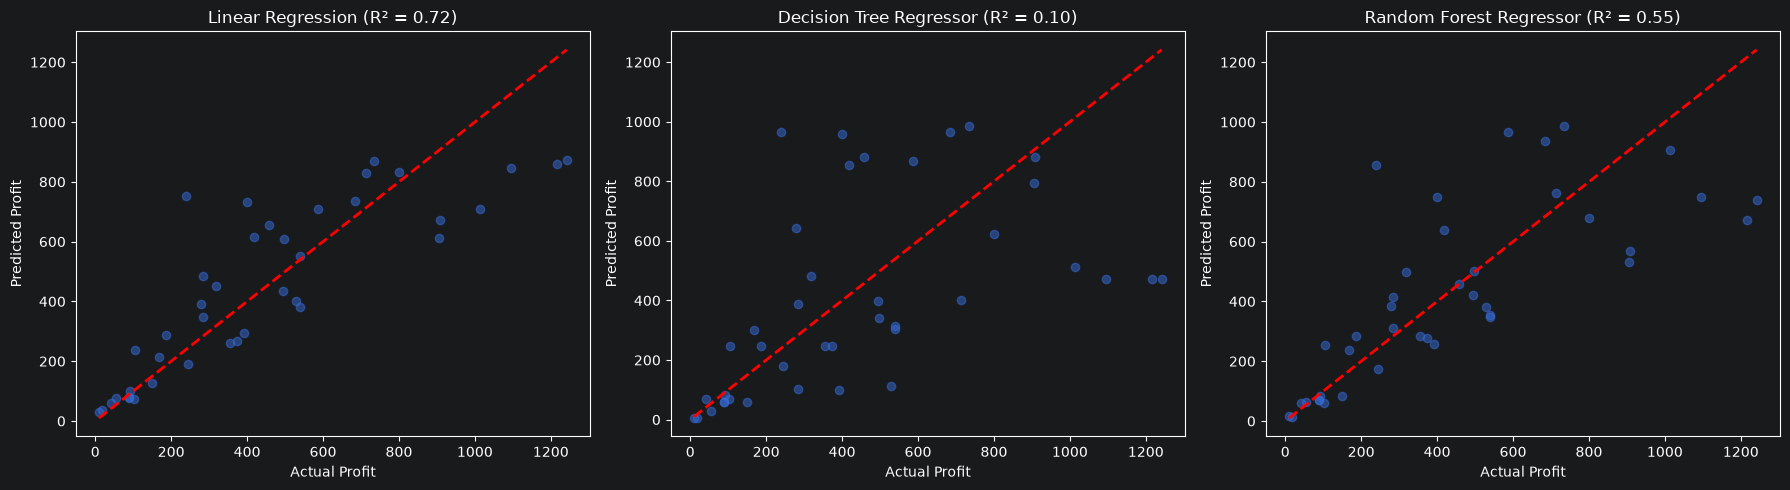

Regression models evaluated and visualized successfully.


<Figure size 640x480 with 0 Axes>

In [13]:
# Visualize the results and interpret the findings
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, result) in enumerate(regression_results.items()):
    axes[i].scatter(y_test_reg, result['predicted_profit'], alpha=0.5)
    axes[i].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
    axes[i].set_title(f"{name} (R² = {result['R-squared']:.2f})")
    axes[i].set_xlabel('Actual Profit')
    axes[i].set_ylabel('Predicted Profit')

plt.tight_layout()
plt.show()
print("Regression models evaluated and visualized successfully.")
plt.savefig('regression_model_evaluation.png')